In [1]:
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
from pathlib import Path

/home/heathosc/Projects/igem-toronto/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
np.random.seed(42)

In [3]:
control_embeds = np.load('../data/family_embedding_controls.esm2-150M.d640.n517840.npz', allow_pickle=True)
real_embeds = np.load('../data/family_embeddings.esm2-150M.d640.n64730.npz', allow_pickle=True)

In [4]:
merged_embeds = np.concatenate([control_embeds['embeddings'], real_embeds['embeddings']])

In [5]:
reducer = umap.UMAP(random_state=42)
embedding_2d = reducer.fit_transform(merged_embeds)

/home/heathosc/Projects/igem-toronto/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [7]:
df = pd.DataFrame(embedding_2d, columns=['x', 'y'])
df.to_csv('../data/controls_umap.csv', index=False)

In [5]:
df = pd.read_csv("../data/controls_umap.csv")

In [6]:
# join df with labels from merged_embeds['labels'] and plot
labels = np.concatenate([control_embeds['accession_ids'], real_embeds['family_ids']])
real_or_control = np.concatenate([np.zeros_like(control_embeds['accession_ids']), np.ones_like(real_embeds['family_ids'])])
variants = np.concatenate([control_embeds['variants'], np.array(["real"] * real_embeds['family_ids'].shape[0])])
df['label'] = labels
df['real'] = real_or_control
df['source'] = variants

In [7]:
fragments = df[df['source'] == 'rand_fragment']
labels = np.tile(['30%_fragment', '60%_fragment', '90%_fragment'], len(fragments) // 3)
df.loc[fragments.index, 'source'] = labels

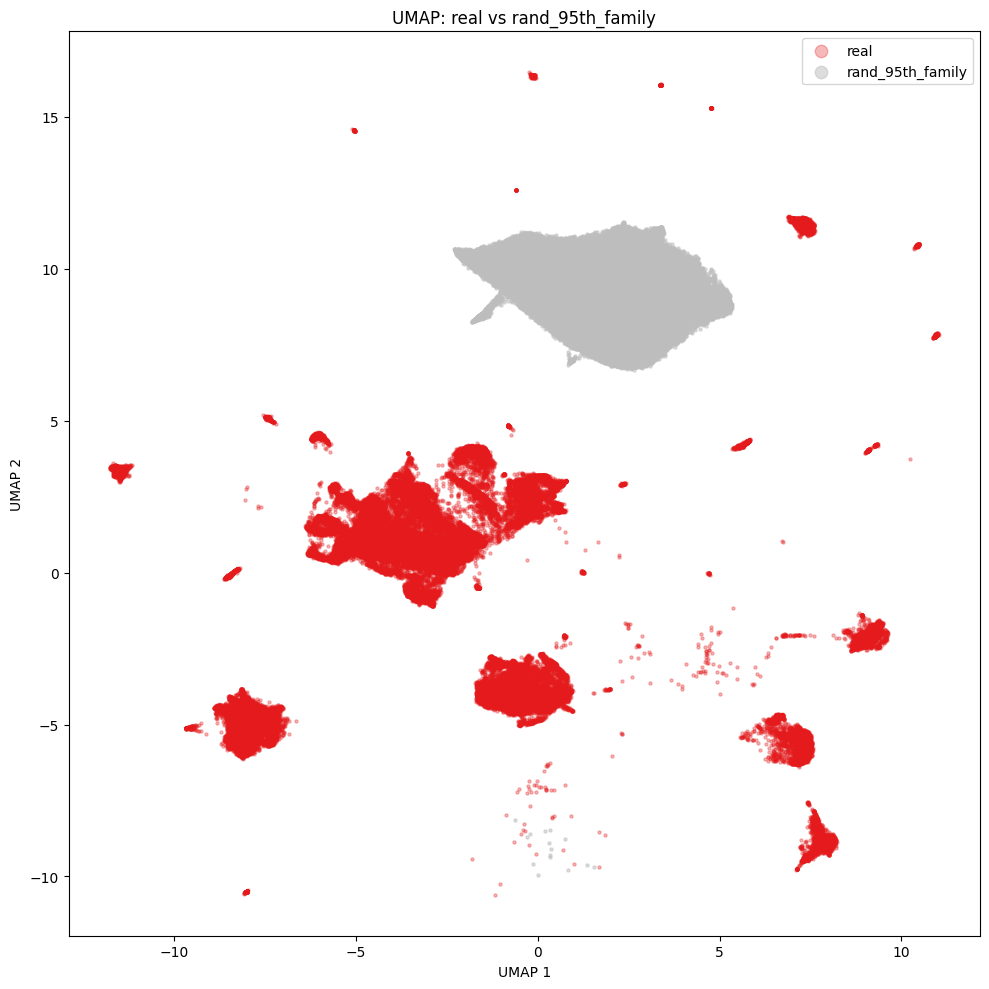

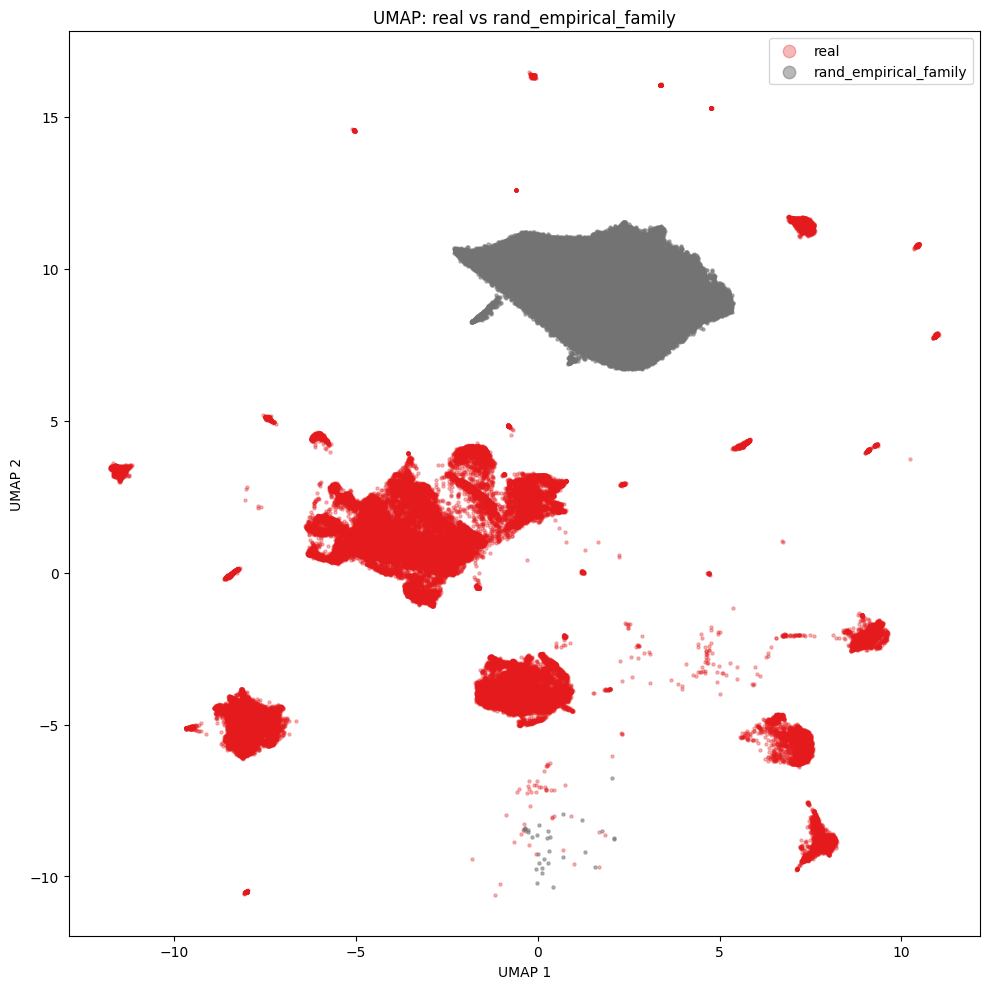

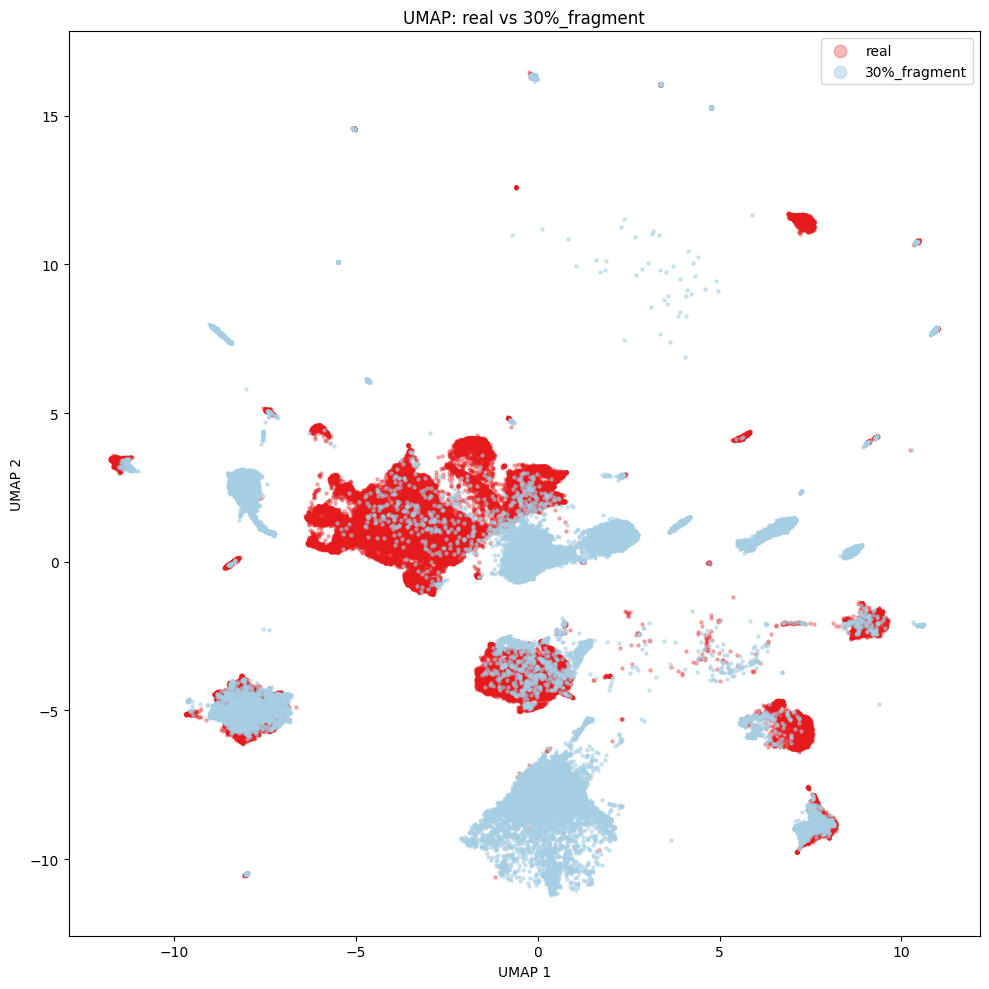

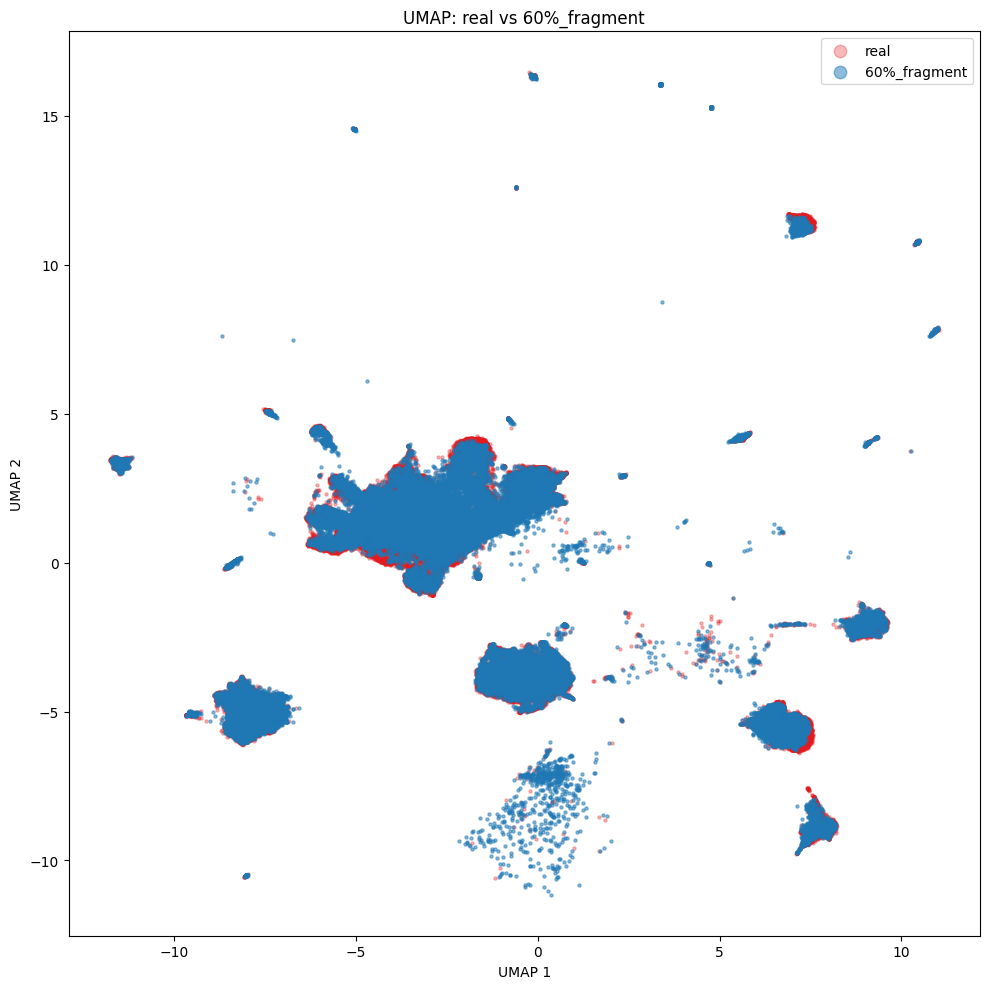

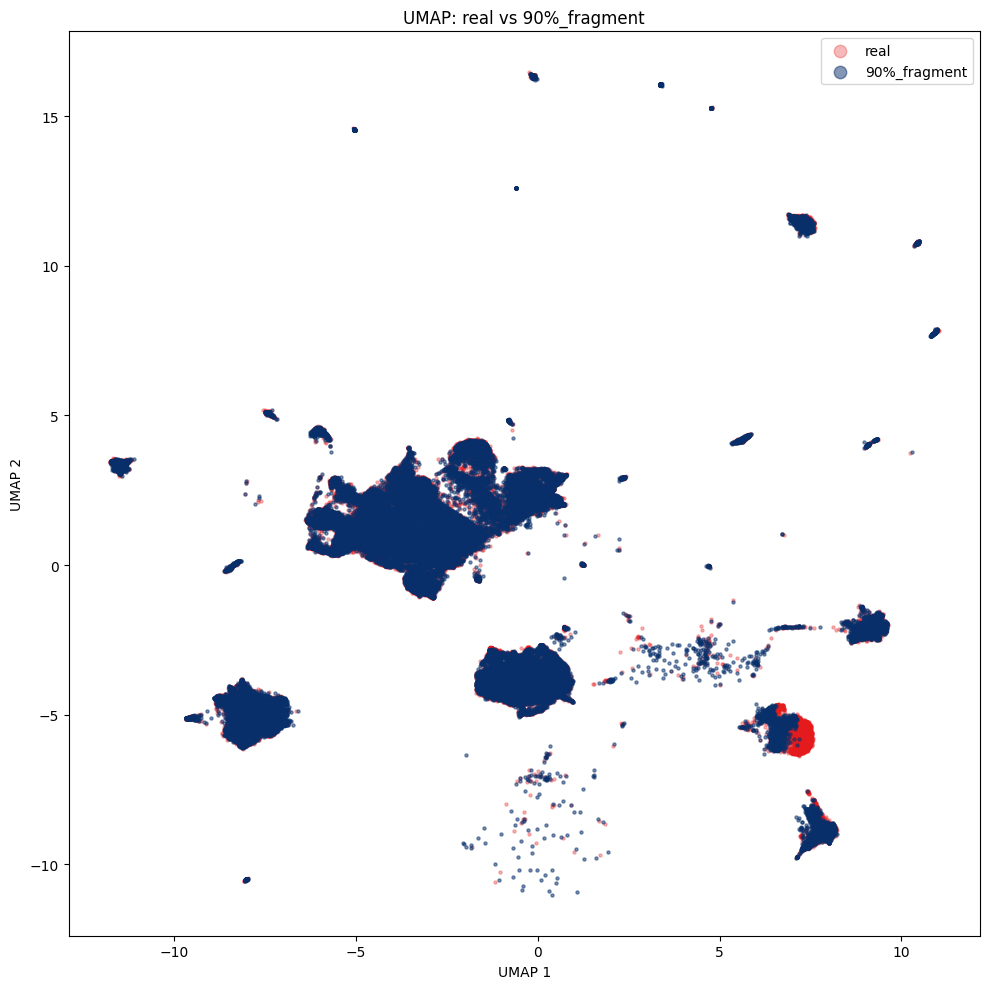

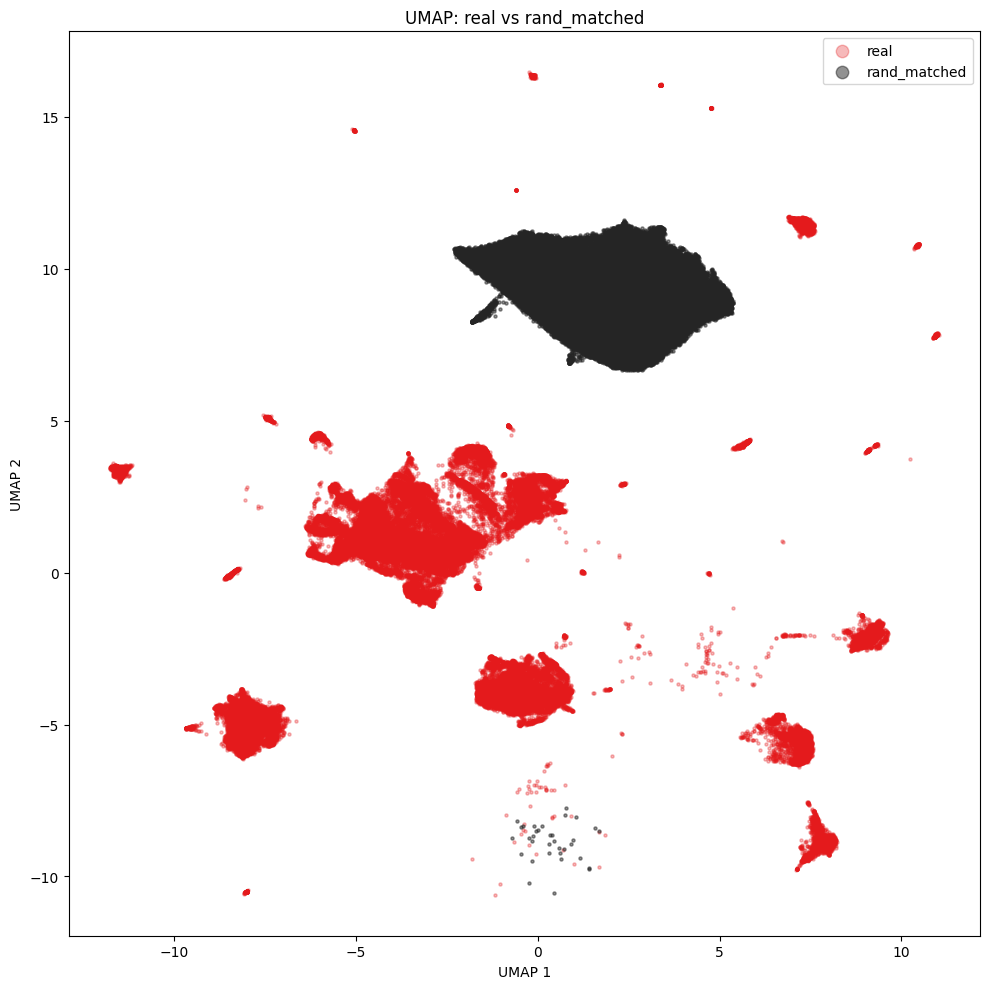

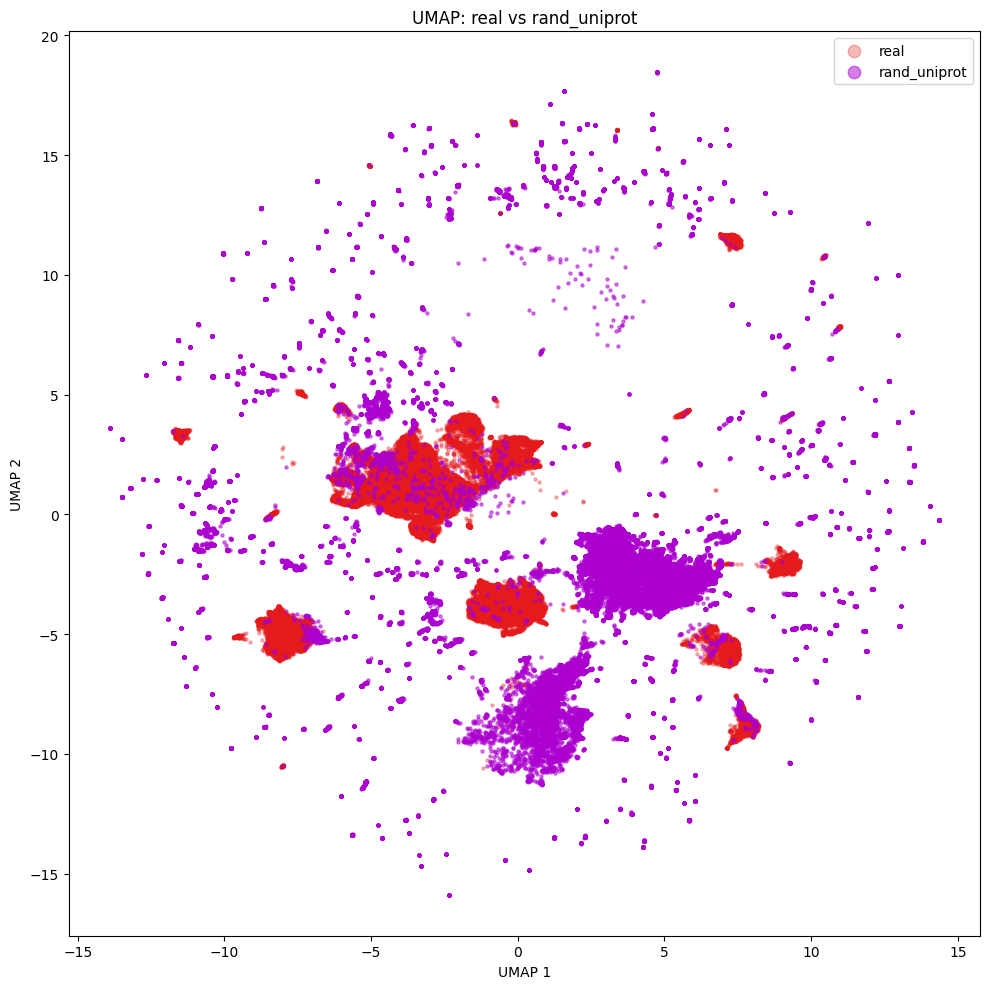

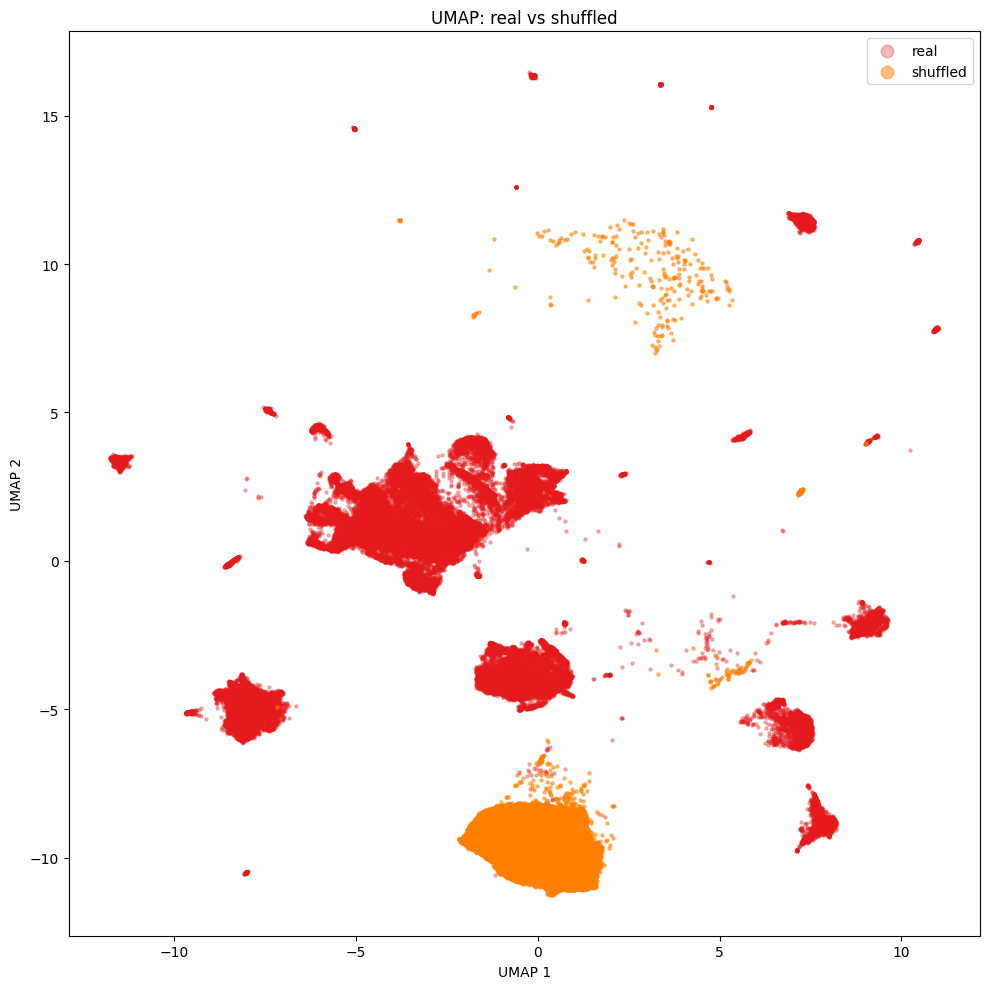

In [8]:
real = df[df['source'] == 'real']
controls = [s for s in df['source'].unique() if s != 'real']
colors = {'real': '#e41a1c',
 '30%_fragment': '#a6cee3',
 '60%_fragment': '#1f78b4',
 '90%_fragment': '#08306b',
 'rand_95th_family': '#bdbdbd',
 'rand_empirical_family': '#737373',
 'rand_matched': '#252525',
 'rand_uniprot': '#ab00cf',
 'shuffled': '#ff7f00'}

for source in controls:
    group = df[df['source'] == source]
    fig, ax = plt.subplots(figsize=(10, 10))

    ax.scatter(real['x'], real['y'], s=5, alpha=0.3, color='#e41a1c', label='real')
    ax.scatter(group['x'], group['y'], s=5, alpha=0.5,
               color=colors.get(source, '#888888'), label=source)

    ax.set_title(f'UMAP: real vs {source}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(markerscale=4)

    plt.tight_layout()
    plt.savefig(Path(f'../plots/real_vs_{source}.png'), dpi=150)
    plt.show()

In [9]:
df.to_csv('../data/controls_umap_labeled.csv', index=False)

In [12]:
df = pd.read_csv('../data/controls_umap_labeled.csv')

/tmp/ipykernel_21751/2991281301.py:1: DtypeWarning: Columns (0: label) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/controls_umap_labeled.csv')


In [17]:
from scipy.spatial.distance import cdist

# Average pairwise distance across all points (sampled — full matrix is too large)
sample_size = 5000
# randomly sample "real" and "control" points to get a representative estimate of global distance distribution
sample_real = df[df['real'] == 1][['x', 'y']].sample(sample_size, random_state=42).values
sample_control = df[df['real'] != 0][['x', 'y']].sample(sample_size, random_state=42).values
avg_global_dist = cdist(sample_real, sample_real).mean()
print(f"Average pairwise distance (sample n={sample_size}): {avg_global_dist:.4f}")

# Matched distance: after interleaved relabelling each group has exactly n_real rows,
# positionally aligned with real sequences
real_pts = df[df['source'] == 'real'][['x', 'y']].values

for source in ['30%_fragment', '60%_fragment', '90%_fragment']:
    frag_pts = df[df['source'] == source][['x', 'y']].values
    dists = np.linalg.norm(frag_pts - real_pts, axis=1)
    print(f"Average matched distance ({source} vs real): {dists.mean():.4f}  (std: {dists.std():.4f})")

Average pairwise distance (sample n=5000): 7.7443
Average matched distance (30%_fragment vs real): 6.9154  (std: 4.9091)
Average matched distance (60%_fragment vs real): 0.6246  (std: 1.7473)
Average matched distance (90%_fragment vs real): 0.1632  (std: 0.7398)
